In [1]:
import os
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

import matplotlib.pyplot as plt
import pandas as pd
import pingouin as pg
import scipy.stats as stats
import statsmodels.api as sm
from dotenv import load_dotenv

from multipred.plotting import barplot_morey, barplot_morey_maineffect

In [2]:
load_dotenv("../../.env")
PROJECT_PATH = os.getenv("PROJECT_PATH")
DATA_PATH = f"{PROJECT_PATH}/data"

# Loading and preparing data

In [3]:
# Loading dataframe
df = pd.read_csv(f"{DATA_PATH}/derivatives/behavioral_raw/main/group_maintask_data.csv")
# rename column "outcome" to "correct"
df.rename(columns={"outcome": "correct", "id": "subj"}, inplace=True)
# change values of v_pred column, o if VP 1 if EXP
df["v_pred"] = df["v_pred"].map({"VP": 0, "EXP": 1})
df["a_pred"] = df["a_pred"].map({"VP": 0, "EXP": 1})

df = df[df["subj"]!="sub-15"]
df = df[df["catch"]==0]

In [12]:
# describe sample demographics
print("Describe age")
print(df.groupby("subj")["age"].first().describe())
# Count the number of female participants
gender_by_id = df.groupby('subj')['gender'].first()
num_females = (gender_by_id == 'F').sum()
print(f"number of female participants: {num_females}")

Describe age
count    25.000000
mean     21.480000
std       3.292922
min      18.000000
25%      19.000000
50%      20.000000
75%      23.000000
max      29.000000
Name: age, dtype: float64
number of female participants: 15


In [4]:
def RT_filter(df):
    # this function was used to filter those trials with a RT that are 3 standard deviations away from the mean
    rt_mean = df['RT'].mean()
    up_lim = rt_mean + 3 * df['RT'].std() # 
    x = df.loc[df['RT'] < up_lim, : ]
    return x #the same dataframe with RT filtered

In [5]:
df = df.groupby("subj").apply(RT_filter).reset_index(drop=True)

/tmp/ipykernel_10508/915597757.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("subj").apply(RT_filter).reset_index(drop=True)


## Effects of visual and auditory predictions

### Visual

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,0.416226,24,two-sided,0.680944,"[-0.01, 0.02]",0.068005,0.228,0.062309


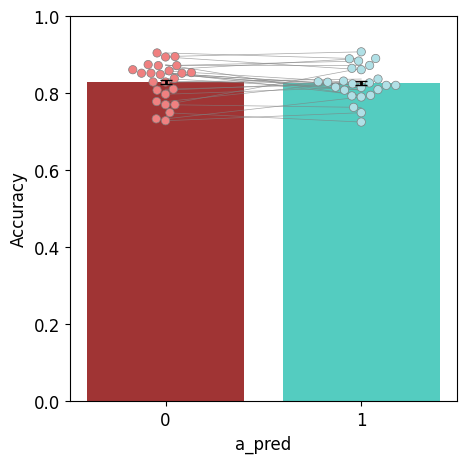

In [6]:
# Accuracy
dx = "a_pred"
dy = "correct"
id = "subj"
modality = "auditory"
dat = df.groupby([id, dx], as_index=0)[dy].mean()

palette1 = ["firebrick", "turquoise"]; palette2 = ["lightcoral", "powderblue"]
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
barplot_morey_maineffect(dat, dx, dy, palette1, palette2, True, True, True, ax)
ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
a = dat[dat[dx]==0][dy].values
b = dat[dat[dx]==1][dy].values
pg.ttest(a, b, paired=True)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,1.001021,24,two-sided,0.326803,"[-0.01, 0.02]",0.040433,0.331,0.054332


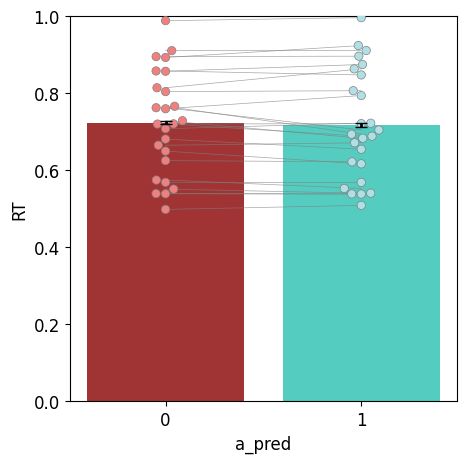

In [30]:
# Accuracy
dx = "a_pred"
dy = "RT"
id = "subj"
modality = "visual"
dat = df.groupby([id, dx], as_index=0)[dy].mean() # df[df.modality==modality]

palette1 = ["firebrick", "turquoise"]; palette2 = ["lightcoral", "powderblue"]
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
barplot_morey_maineffect(dat, dx, dy, palette1, palette2, True, True, True, ax)
ax.set_ylim(0, 1)
ax.set_ylabel("RT")
a = dat[dat[dx]==0][dy].values
b = dat[dat[dx]==1][dy].values
pg.ttest(a, b, paired=True)

   modality   correct
0  auditory  0.817078
1    visual  0.837395
               T  dof alternative     p-val         CI95%   cohen-d   BF10  \
T-test  2.020391   24   two-sided  0.054638  [-0.0, 0.04]  0.411167  1.195   

           power  
T-test  0.505361  


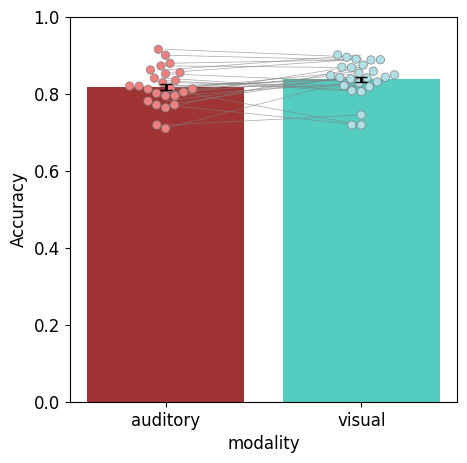

In [35]:
# Accuracy
dx = "modality"
dy = "correct"
id = "subj"
modality = "auditory"
dat = df.groupby([id, dx], as_index=0)[dy].mean()

palette1 = ["firebrick", "turquoise"]; palette2 = ["lightcoral", "powderblue"]
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
barplot_morey_maineffect(dat, dx, dy, palette1, palette2, True, True, True, ax)
ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")

print(df.groupby([dx], as_index=0)[dy].mean())
a = dat[dat[dx]=="visual"][dy].values
b = dat[dat[dx]=="auditory"][dy].values
print(pg.ttest(a, b, paired=True))

              Source        SS  ddof1  ddof2        MS         F     p-unc  \
0           modality  0.007279      1     24  0.007279  1.994378  0.170720   
1             v_pred  0.001325      1     24  0.001325  1.144071  0.295434   
2  modality * v_pred  0.001139      1     24  0.001139  0.549302  0.465794   

   p-GG-corr       np2  eps  
0   0.170720  0.076723  1.0  
1   0.295434  0.045501  1.0  
2   0.465794  0.022375  1.0  


c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\pingouin\pairwise.py:28: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)


,Contrast,modality,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,modality,-,auditory,visual,True,True,-1.412225,24.0,two-sided,0.170720,NaN,NaN,0.509,-0.320333
1,v_pred,-,0,1,True,True,1.069612,24.0,two-sided,0.295434,NaN,NaN,0.352,0.155416
2,modality * v_pred,auditory,0,1,True,True,1.183238,24.0,two-sided,0.248304,0.496607,fdr_bh,0.394,0.231083
3,modality * v_pred,visual,0,1,True,True,0.048748,24.0,two-sided,0.961523,0.961523,fdr_bh,0.211,0.008757


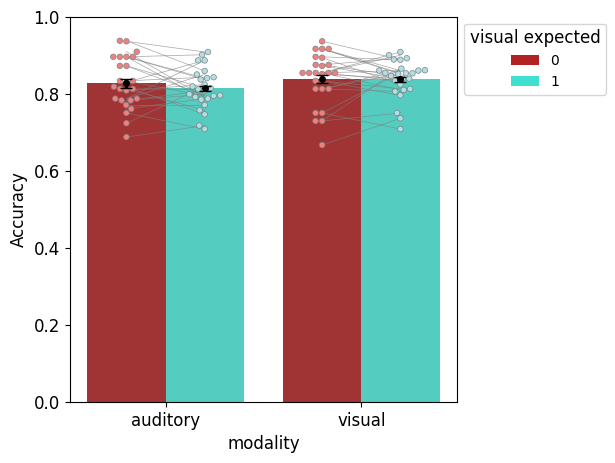

In [15]:
# Accuracy, by attention
hue = "v_pred"
dx = "modality"
dy = "correct"
id = "subj"
dat = df.groupby([id, dx, hue], as_index=0)[dy].mean()

palette1 = ["firebrick", "turquoise"]; palette2 = ["lightcoral", "powderblue"]
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
barplot_morey(dat, dx, dy, hue, "visual expected", palette1, palette2, True, True, True, ax)
ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
print(pg.rm_anova(dv=dy, within= [dx, hue], subject=id,correction='auto', effsize = "np2", data=dat))
pg.pairwise_ttests(dv=dy, within=[dx, hue], subject=id, data=dat, padjust='fdr_bh')

,Source,ddof1,ddof2,F,p-unc,np2,eps
0,v_pred,1,24,0.04692,0.830343,0.001951,1.0


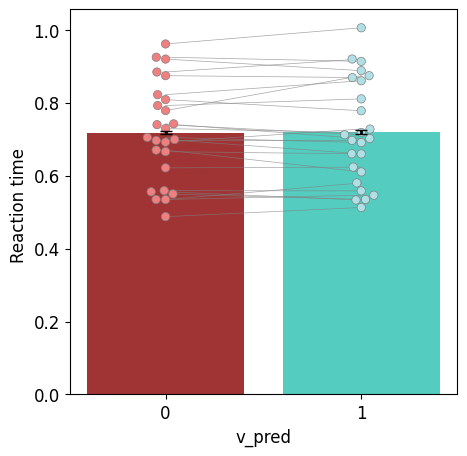

In [8]:
#RT
dx = "v_pred"
dy = "RT"
id = "subj"
dat = df.groupby([id, dx], as_index=0)[dy].mean()

palette1 = ["firebrick", "turquoise"]; palette2 = ["lightcoral", "powderblue"]
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
barplot_morey_maineffect(dat, dx, dy, palette1, palette2, True, True, True, ax)
ax.set_ylabel("Reaction time ")
pg.rm_anova(dv=dy, within= [dx], subject=id,correction='auto', effsize = "np2", data=dat)

              Source        SS  ddof1  ddof2        MS          F     p-unc  \
0           modality  0.150510      1     24  0.150510  22.928410  0.000071   
1             v_pred  0.000051      1     24  0.000051   0.042564  0.838288   
2  modality * v_pred  0.005160      1     24  0.005160   6.064486  0.021354   

   p-GG-corr       np2  eps  
0   0.000071  0.488583  1.0  
1   0.838288  0.001770  1.0  
2   0.021354  0.201716  1.0  


c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\pingouin\pairwise.py:28: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)


,Contrast,modality,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,modality,-,auditory,visual,True,True,4.788362,24.0,two-sided,0.000071,NaN,NaN,365.075,0.532227
1,v_pred,-,0,1,True,True,-0.206311,24.0,two-sided,0.838288,NaN,NaN,0.215,-0.010132
2,modality * v_pred,auditory,0,1,True,True,-1.658007,24.0,two-sided,0.110331,0.143419,fdr_bh,0.698,-0.098089
3,modality * v_pred,visual,0,1,True,True,1.512678,24.0,two-sided,0.143419,0.143419,fdr_bh,0.576,0.097421


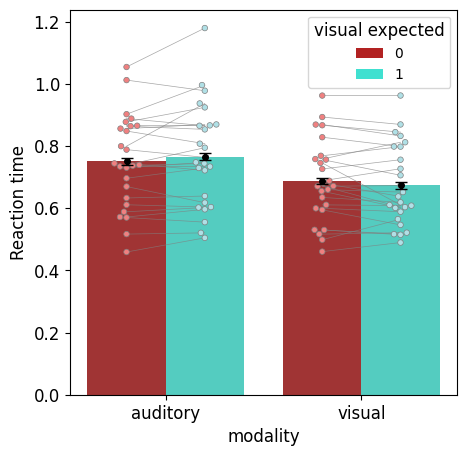

In [9]:
# Accuracy, by attention
hue = "v_pred"
dx = "modality"
dy = "RT"
id = "subj"
dat = df.groupby([id, dx, hue], as_index=0)[dy].mean()

palette1 = ["firebrick", "turquoise"]; palette2 = ["lightcoral", "powderblue"]
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
barplot_morey(dat, dx, dy, hue, "visual expected", palette1, palette2, True, True, True, ax)
ax.set_ylabel("Reaction time")
print(pg.rm_anova(dv=dy, within= [dx, hue], subject=id,correction='auto', effsize = "np2", data=dat))
pg.pairwise_ttests(dv=dy, within=[dx, hue], subject=id, data=dat, padjust='fdr_bh')

### Auditory

,Source,ddof1,ddof2,F,p-unc,np2,eps
0,a_pred,1,24,0.173244,0.680944,0.007167,1.0


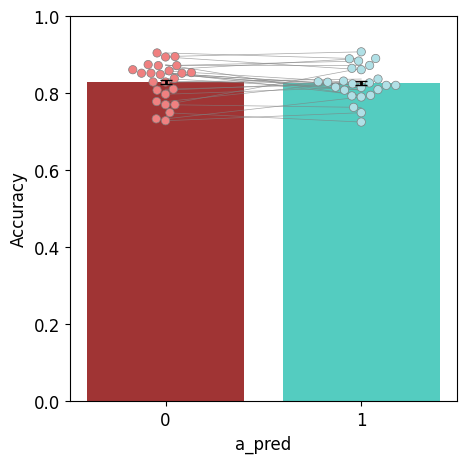

In [10]:
# Accuracy
dx = "a_pred"
dy = "correct"
id = "subj"
dat = df.groupby([id, dx], as_index=0)[dy].mean()

palette1 = ["firebrick", "turquoise"]; palette2 = ["lightcoral", "powderblue"]
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
barplot_morey_maineffect(dat, dx, dy, palette1, palette2, True, True, True, ax)
ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
pg.rm_anova(dv=dy, within= [dx], subject=id,correction='auto', effsize = "np2", data=dat)

              Source        SS  ddof1  ddof2        MS         F     p-unc  \
0           modality  0.011481      1     24  0.011481  3.548884  0.071757   
1             a_pred  0.000255      1     24  0.000255  0.169871  0.683885   
2  modality * a_pred  0.000088      1     24  0.000088  0.051156  0.822980   

   p-GG-corr       np2  eps  
0   0.071757  0.128821  1.0  
1   0.683885  0.007028  1.0  
2   0.822980  0.002127  1.0  


c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\pingouin\pairwise.py:28: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)


,Contrast,modality,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,modality,-,auditory,visual,True,True,-1.883848,24.0,two-sided,0.071757,NaN,NaN,0.967,-0.406294
1,a_pred,-,0,1,True,True,0.412154,24.0,two-sided,0.683885,NaN,NaN,0.228,0.066048
2,modality * a_pred,auditory,0,1,True,True,0.112515,24.0,two-sided,0.911351,0.911351,fdr_bh,0.212,0.022050
3,modality * a_pred,visual,0,1,True,True,0.462594,24.0,two-sided,0.647822,0.911351,fdr_bh,0.233,0.083818


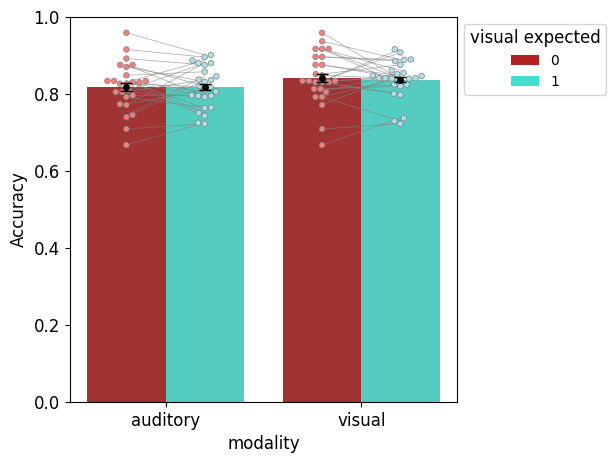

In [11]:
# Accuracy, by attention
hue = "a_pred"
dx = "modality"
dy = "correct"
id = "subj"
dat = df.groupby([id, dx, hue], as_index=0)[dy].mean()

palette1 = ["firebrick", "turquoise"]; palette2 = ["lightcoral", "powderblue"]
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
barplot_morey(dat, dx, dy, hue, "visual expected", palette1, palette2, True, True, True, ax)
ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
print(pg.rm_anova(dv=dy, within= [dx, hue], subject=id,correction='auto', effsize = "np2", data=dat))
pg.pairwise_ttests(dv=dy, within=[dx, hue], subject=id, data=dat, padjust='fdr_bh')

,Source,ddof1,ddof2,F,p-unc,np2,eps
0,a_pred,1,24,1.002044,0.326803,0.040078,1.0


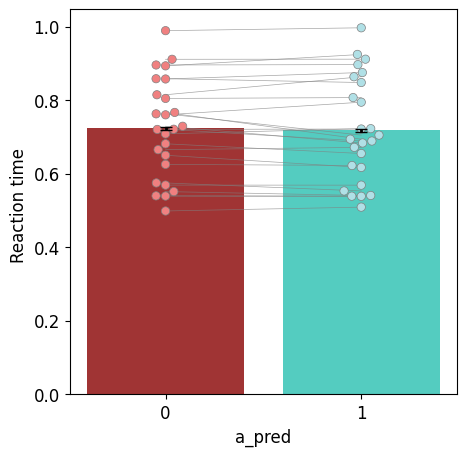

In [12]:
#RT
dx = "a_pred"
dy = "RT"
id = "subj"
dat = df.groupby([id, dx], as_index=0)[dy].mean()

palette1 = ["firebrick", "turquoise"]; palette2 = ["lightcoral", "powderblue"]
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
barplot_morey_maineffect(dat, dx, dy, palette1, palette2, True, True, True, ax)
ax.set_ylabel("Reaction time ")
pg.rm_anova(dv=dy, within= [dx], subject=id,correction='auto', effsize = "np2", data=dat)

              Source        SS  ddof1  ddof2        MS          F     p-unc  \
0           modality  0.177641      1     24  0.177641  25.873549  0.000033   
1             a_pred  0.000866      1     24  0.000866   1.095806  0.305617   
2  modality * a_pred  0.000026      1     24  0.000026   0.030862  0.862021   

   p-GG-corr       np2  eps  
0   0.000033  0.518783  1.0  
1   0.305617  0.043665  1.0  
2   0.862021  0.001284  1.0  


c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\pingouin\pairwise.py:28: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)


,Contrast,modality,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,modality,-,auditory,visual,True,True,5.086605,24.0,two-sided,0.000033,NaN,NaN,722.887,0.577854
1,a_pred,-,0,1,True,True,1.046808,24.0,two-sided,0.305617,NaN,NaN,0.345,0.041913
2,modality * a_pred,auditory,0,1,True,True,0.560422,24.0,two-sided,0.580386,0.580386,fdr_bh,0.243,0.030176
3,modality * a_pred,visual,0,1,True,True,0.935608,24.0,two-sided,0.358795,0.580386,fdr_bh,0.313,0.052377


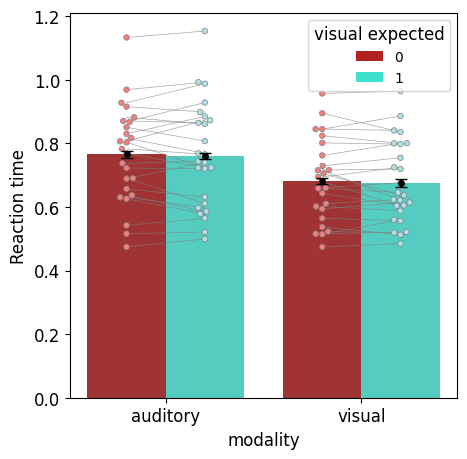

In [13]:
# Accuracy, by attention
hue = "a_pred"
dx = "modality"
dy = "RT"
id = "subj"
dat = df.groupby([id, dx, hue], as_index=0)[dy].mean()

palette1 = ["firebrick", "turquoise"]; palette2 = ["lightcoral", "powderblue"]
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
barplot_morey(dat, dx, dy, hue, "visual expected", palette1, palette2, True, True, True, ax)
ax.set_ylabel("Reaction time")
print(pg.rm_anova(dv=dy, within= [dx, hue], subject=id,correction='auto', effsize = "np2", data=dat))
pg.pairwise_ttests(dv=dy, within=[dx, hue], subject=id, data=dat, padjust='fdr_bh')

## Effects of visual explicit knowledge on performance

In [9]:
df["v_learned"] = df["v_learned"].astype("category")
df["a_pred"] = df["a_pred"].astype("category")
df["v_pred"] = df["v_pred"].astype("category")

In [19]:
df[(df["modality"]=="visual") & (df["a_pred"]==1)]

,Unnamed: 0,subj,age,gender,hand,exp_date,start_mod,block,modality,ntrial,...,seqs,pred,ign_pred,ign_mod,relevant_expected,irrelevant_expected,v_learned,a_learned,att_learned,ign_learned
2,9794,sub-02,19,F,R,2022_Oct_03_1724,0,0,visual,2,...,"['two.csv', 'six.csv', 'one.csv', 'three.csv',...",EXP,EXP,auditory,1,1,1,1,1,1
3,9795,sub-02,19,F,R,2022_Oct_03_1724,0,0,visual,3,...,"['two.csv', 'six.csv', 'one.csv', 'three.csv',...",EXP,EXP,auditory,1,1,1,0,1,0
4,9796,sub-02,19,F,R,2022_Oct_03_1724,0,0,visual,4,...,"['two.csv', 'six.csv', 'one.csv', 'three.csv',...",VP,EXP,auditory,0,1,1,1,1,1
5,9797,sub-02,19,F,R,2022_Oct_03_1724,0,0,visual,5,...,"['two.csv', 'six.csv', 'one.csv', 'three.csv',...",EXP,EXP,auditory,1,1,1,0,1,0
6,9798,sub-02,19,F,R,2022_Oct_03_1724,0,0,visual,6,...,"['two.csv', 'six.csv', 'one.csv', 'three.csv',...",EXP,EXP,auditory,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9391,6454,sub-27,20,M,R,2022_Oct_27_1857,0,4,visual,62,...,"['three.csv', 'one.csv', 'six.csv', 'five.csv'...",EXP,EXP,auditory,1,1,0,1,0,1
9392,6455,sub-27,20,M,R,2022_Oct_27_1857,0,4,visual,63,...,"['three.csv', 'one.csv', 'six.csv', 'five.csv'...",EXP,EXP,auditory,1,1,1,1,1,1
9393,6456,sub-27,20,M,R,2022_Oct_27_1857,0,4,visual,64,...,"['three.csv', 'one.csv', 'six.csv', 'five.csv'...",VP,EXP,auditory,0,1,0,1,0,1
9395,6458,sub-27,20,M,R,2022_Oct_27_1857,0,4,visual,66,...,"['three.csv', 'one.csv', 'six.csv', 'five.csv'...",VP,EXP,auditory,0,1,1,1,1,1


In [20]:
dat = df[(df["modality"]=="visual") & (df["a_pred"]==1)].copy()
md = sm.MixedLM.from_formula("correct ~ v_pred * v_learned", data=dat, groups=dat["subj"])
mdf = md.fit()
print(mdf.summary())

                Mixed Linear Model Regression Results
Model:                 MixedLM     Dependent Variable:     correct   
No. Observations:      3569        Method:                 REML      
No. Groups:            25          Scale:                  0.1357    
Min. group size:       139         Log-Likelihood:         -1522.6742
Max. group size:       144         Converged:              Yes       
Mean group size:       142.8                                         
---------------------------------------------------------------------
                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                   0.834    0.022 37.648 0.000  0.790  0.877
v_pred[T.1]                 0.000    0.022  0.021 0.983 -0.043  0.044
v_learned[T.1]              0.006    0.032  0.180 0.857 -0.057  0.069
v_pred[T.1]:v_learned[T.1] -0.002    0.033 -0.047 0.962 -0.067  0.064
Group Var                   0.002   

/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [21]:
dat = df[(df["modality"]=="visual")].copy()
md = sm.MixedLM.from_formula("correct ~ v_learned", data=dat, groups=dat["subj"])
mdf = md.fit()
print(mdf.summary())

          Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: correct   
No. Observations:  4760    Method:             REML      
No. Groups:        25      Scale:              0.1345    
Min. group size:   187     Log-Likelihood:     -2001.5665
Max. group size:   192     Converged:          Yes       
Mean group size:   190.4                                 
---------------------------------------------------------
               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept       0.838    0.012 69.356 0.000  0.814  0.862
v_learned[T.1] -0.001    0.015 -0.097 0.923 -0.032  0.029
Group Var       0.002    0.002                           



/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


## Explicit recall phase

In [19]:
df_explicit = pd.read_csv((f'{DATA_PATH}/derivatives/behavioral_raw/training/group_explicit_data.csv'))
df_explicit.rename(columns={"outcome": "correct", "id": "subj"}, inplace=True)
dat = df_explicit[df_explicit.modality == "visual"]
k = dat["correct"].sum() # Number of correct recalls
n = len(dat) ; # Number of trials
stats.binomtest(k, n, p=0.5, alternative="two-sided") # higher than chance

BinomTestResult(k=153, n=208, alternative='two-sided', statistic=0.7355769230769231, pvalue=7.106913122896171e-12)

In [20]:
dat = df_explicit[df_explicit.modality == "auditory"]
k = dat["correct"].sum() # Number of correct recalls
n = len(dat) ; # Number of trials
stats.binomtest(k, n, p=0.5, alternative="two-sided") # higher than chance

BinomTestResult(k=113, n=208, alternative='two-sided', statistic=0.5432692307692307, pvalue=0.23843026889610858)

In [7]:
df_explicit.groupby(["modality"])["correct"].mean()

modality
auditory    0.543269
visual      0.735577
Name: correct, dtype: float64

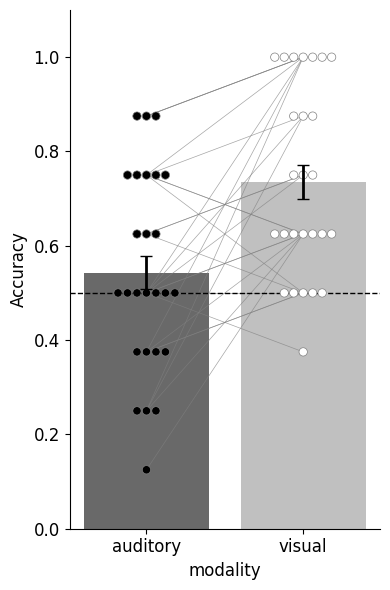

In [17]:
import seaborn as sns

# Accuracy
dx = "modality"
dy = "correct"
id = "subj"
dat = df_explicit.groupby([id, dx], as_index=0)[dy].mean()

palette1 =["dimgray", "silver"]; palette2 = ["black", "white"]
fig, ax = plt.subplots(1, 1, figsize=(4, 6))
barplot_morey_maineffect(dat, dx, dy, palette1, palette2, True, True, True, ax)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Accuracy")
pg.rm_anova(dv=dy, within= [dx], subject=id,correction='auto', effsize = "np2", data=dat)
ax.axhline(y=.5, linestyle='--', color='black', linewidth=1)

plt.tight_layout()
sns.despine()
plt.savefig("figures/behav/accuracy_explicit.svg", dpi=300)